# Neurokit <code>get_segments()</code> Function Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, wget
import pyedflib  # to read EDF files

import neurokit2 as nk  # for ECG preprocessing and segmentation

from scipy.linalg import svd
from scipy.signal import find_peaks

In [2]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [3]:
edf_file = "r01.edf"
edf_path = os.path.join("..", "data", "raw", edf_file)
plot_fig_path = os.path.join("..", "reports", "figures", "2-neurokit-segments")

In [4]:
# Load EDF file
edf = pyedflib.EdfReader(edf_path)

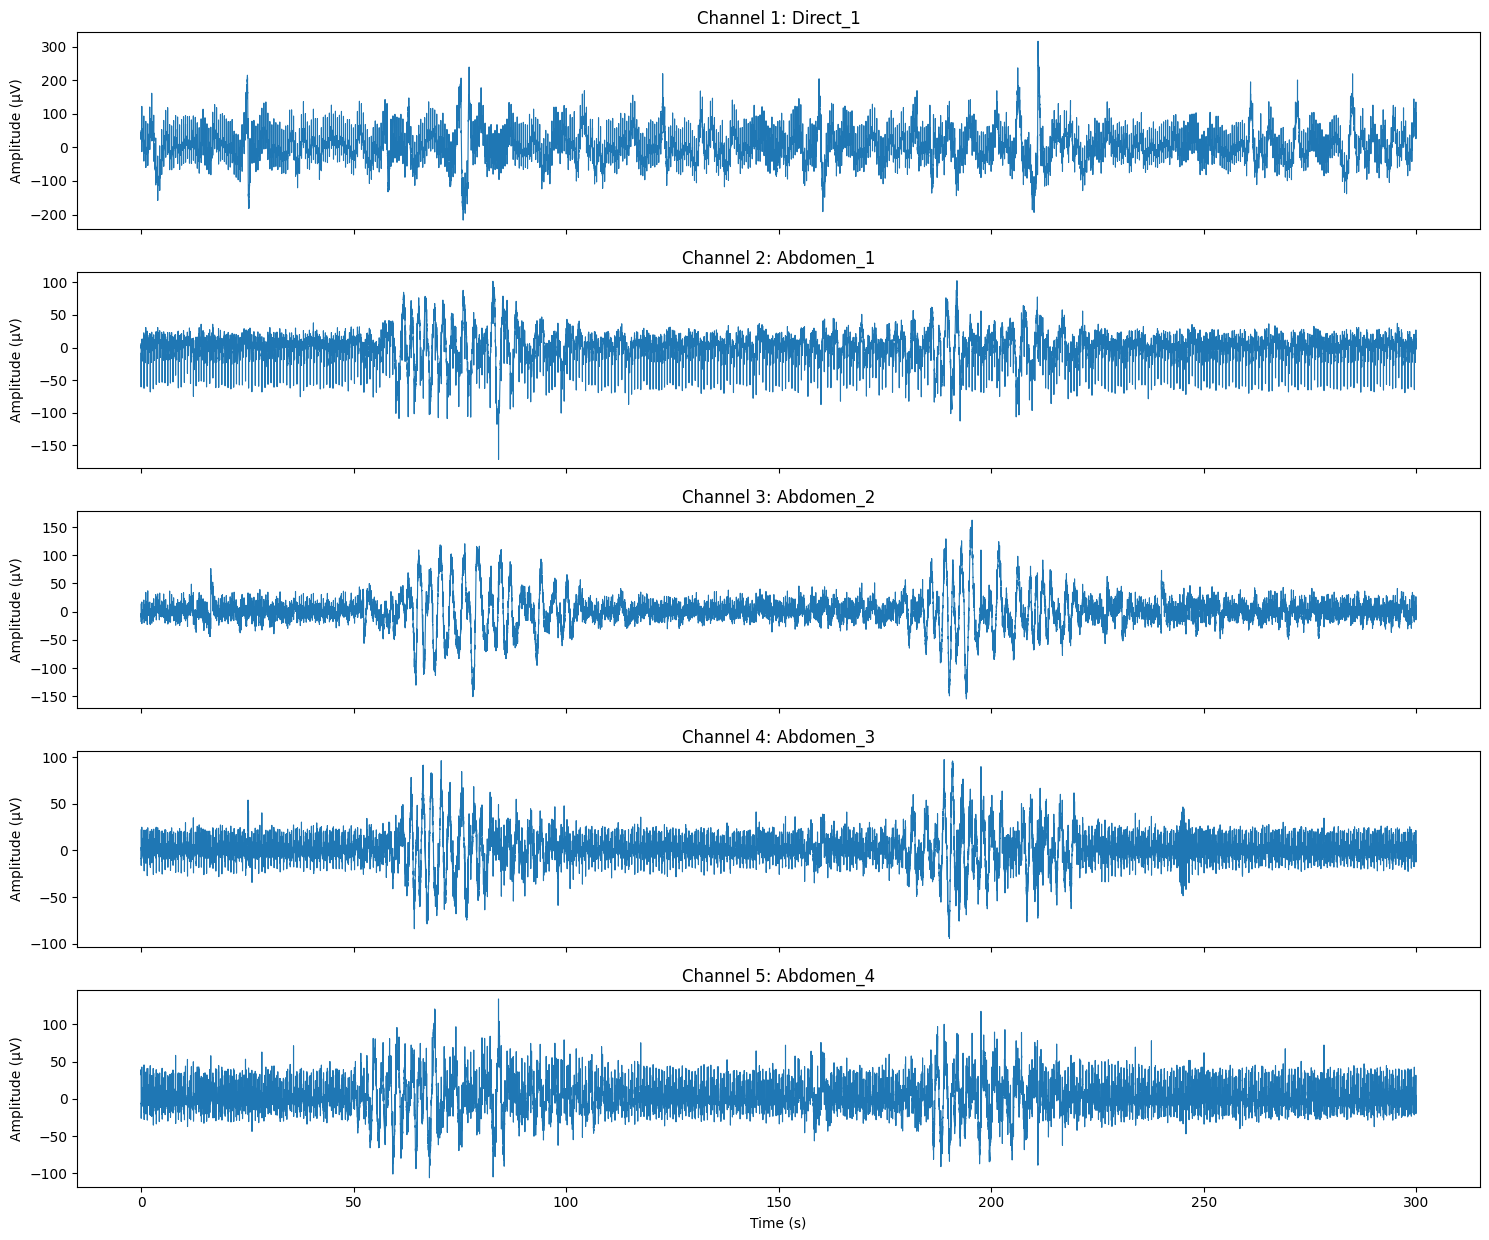

In [5]:
# Get signal info
n_channels = edf.signals_in_file
channel_labels = edf.getSignalLabels()
sampling_rate = edf.getSampleFrequency(0)
signal_duration = edf.getFileDuration()
n_samples = edf.getNSamples()[0]
time_vector = np.linspace(0, signal_duration, n_samples)

# Create subplots
fig, axes = plt.subplots(n_channels, 1, figsize=(15, 2.5 * n_channels), sharex=True)

# Plot each channel with its label
for i in range(n_channels):
    signal = edf.readSignal(i)
    axes[i].plot(time_vector, signal, linewidth=0.8)
    axes[i].set_title(f"Channel {i+1}: {channel_labels[i]}")
    axes[i].set_ylabel("Amplitude (µV)")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(plot_fig_path, '1-full-channels-ecg.png'))
plt.show()

In [6]:
direct_signal = edf.readSignal(0)
abdomen_signal = edf.readSignal(1) # 1 = Abdomen_1, 2 = Abdomen_2, 3 = Abdomen_3, 4 = Abdomen_4

# I will not close the file in order to consult different signals later

onsets, durations, labels = edf.readAnnotations() # starting times, duration (in seconds), labels
print("1st onset:", onsets[0]) # the first onset time in seconds
print("1st peak duration:", durations[0]) # -1 if no duration is given
print("1st label:", labels[0]) # the label of the first annotation

1st onset: 0.183
1st peak duration: -1.0
1st label: QRS


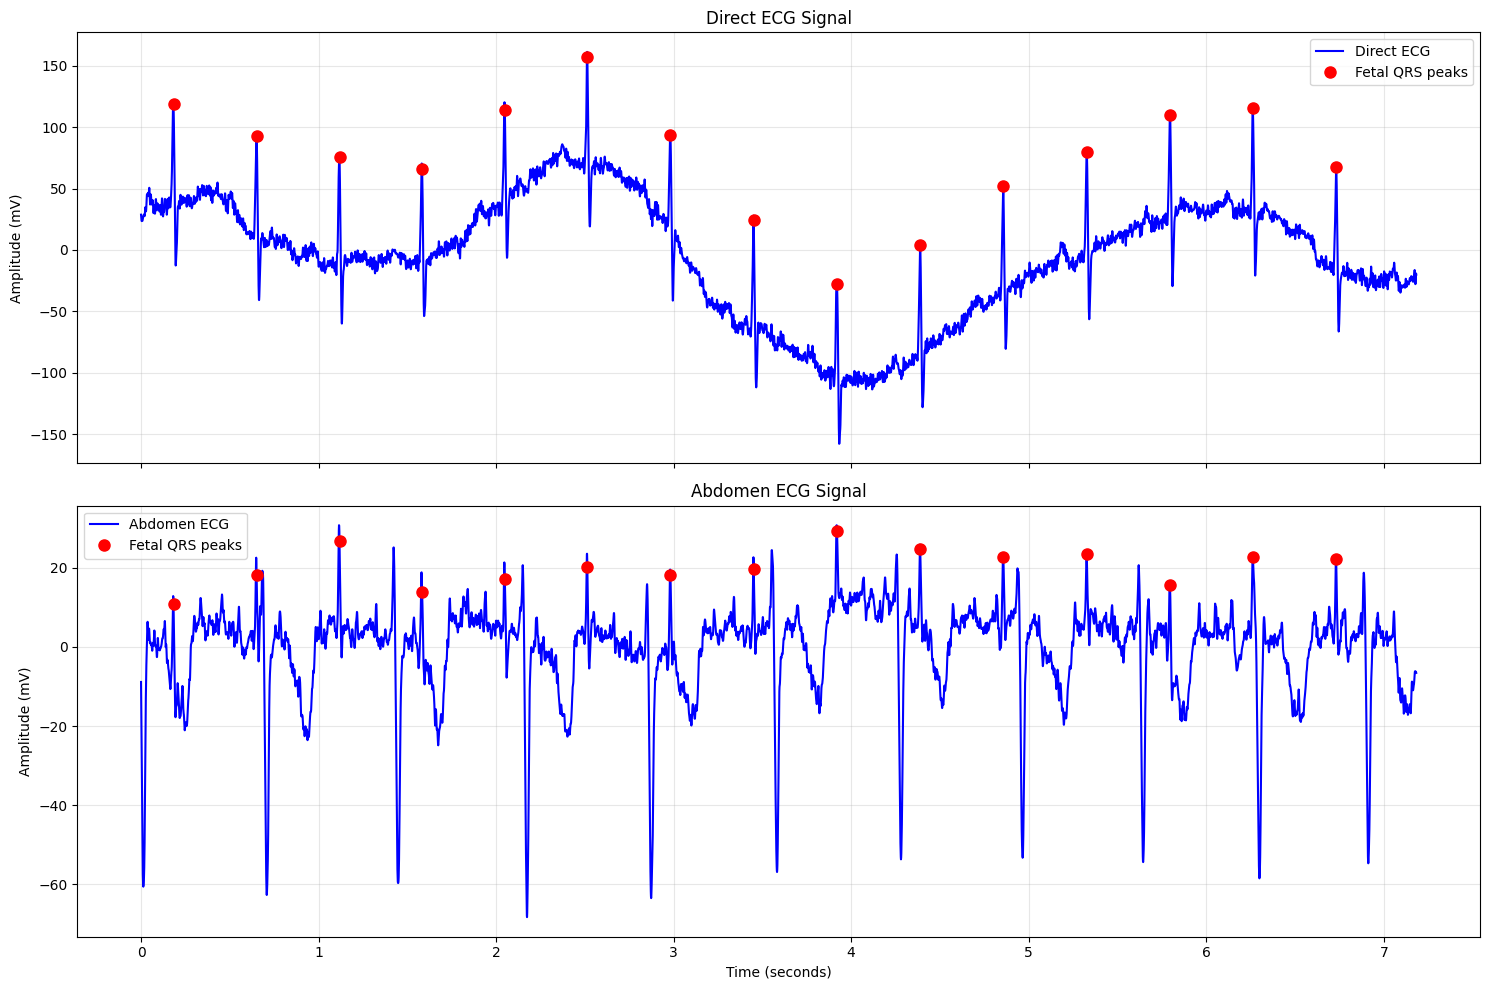

In [7]:
first_onset = onsets[0]
first_label = labels[0]

window_duration = 7.0 # Let's use 5 seconds window
start_time = max(0, first_onset - window_duration)
end_time = first_onset + window_duration

# Convert to sample indices
start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extract the signal segment
direct_signal_segment = direct_signal[start_sample:end_sample]
abdomen_signal_segment = abdomen_signal[start_sample:end_sample]
direct_time_segment = np.linspace(start_time, end_time, len(direct_signal_segment))
abdomen_time_segment = np.linspace(start_time, end_time, len(abdomen_signal_segment))

# Get the onsets within the specified time window and interpolate their values
onsets_in_window = onsets[(onsets >= start_time) & (onsets <= end_time)]
direct_onset_values = np.interp(onsets_in_window, direct_time_segment, direct_signal_segment)
abdomen_onset_values = np.interp(onsets_in_window, abdomen_time_segment, abdomen_signal_segment)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Direct signal
ax1.plot(direct_time_segment, direct_signal_segment, 'b-', linewidth=1.5, label='Direct ECG')
ax1.plot(onsets_in_window, direct_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title(f'Direct ECG Signal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Abdomen signal
ax2.plot(abdomen_time_segment, abdomen_signal_segment, 'b-', linewidth=1.5, label='Abdomen ECG')
ax2.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude (mV)')
ax2.set_title(f'Abdomen ECG Signal')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_fig_path, '2-direct-and-abdomen-segments.png'))
plt.show()

## `ecg_segment()` insight

```python
def ecg_segment(ecg_cleaned, rpeaks=None, sampling_rate=1000, show=False, **kwargs):
```

- `ecg_cleaned` is the input ECG signal, which should already be cleaned
- `rpeaks` is a dictionary of R-peak indices; if not provided, the function will estimate them
- `sampling_rate` is the sampling frequency (default is 1000Hz)
- `show` plots the segmented beats if `True`
- `**kwargs` are passed on to the plotting function


```python
if rpeaks is None:
    _, rpeaks = ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate, correct_artifacts=True)
    rpeaks = rpeaks["ECG_R_Peaks"]
```

> This requires to delve deeper in `ecg_peaks()` function and will be done later.


```python
if len(ecg_cleaned) < sampling_rate * 4:
    raise ValueError("The data length is too small to be segmented.")

```

This code ensures that there is at least 4 seconds of ECG data (at 1000Hz that's 4000 samples), to ensure enough beats for meaningful segmentation.


```python
epochs_start, epochs_end, average_hr = _ecg_segment_window(
    rpeaks=rpeaks, sampling_rate=sampling_rate, desired_length=len(ecg_cleaned)
)
```
> This requires to delve deeper in `_ecg_segment_window()` function and will be done later.


```python
heartbeats = epochs_create(
    ecg_cleaned,
    rpeaks,
    sampling_rate=sampling_rate,
    epochs_start=epochs_start,
    epochs_end=epochs_end,
)
```

> This requires to delve deeper in `epochs_create()` function and will be done later.


```python
last_heartbeat_key = str(np.max(np.array(list(heartbeats.keys()), dtype=int)))
after_last_index = heartbeats[last_heartbeat_key]["Index"] >= len(ecg_cleaned)
for col in ["Signal", "ECG_Raw", "ECG_Clean"]:
    if col in heartbeats[last_heartbeat_key].columns:
        heartbeats[last_heartbeat_key].loc[after_last_index, col] = np.nan
```

Ensures that the final segment (beat) does not exceed the signal length and **pads any values beyond the end of the signal with `NaN`**.


```python
if show is not False:
    ax = _ecg_segment_plot(heartbeats, heartrate=average_hr, ytitle="ECG", **kwargs)
if show == "return":
    return ax

return heartbeats
```

Plots the heartbeats and returns a dictionary of heartbeats, each as a DataFrame.


## `ecg_peaks()` insight

```python
info = {"method_peaks": method.lower(), "method_fixpeaks": "None"}
```

Initializes a dictionary to store metadata about the method used for peak detection and (if used) correction.


```python
info.update(ecg_findpeaks(ecg_cleaned, sampling_rate=sampling_rate, method=info["method_peaks"], **kwargs))
```

Calls `ecg_findpeaks()` using the chosen method (`neurokit` by default). The result is a dictionary which is merged into `info`.

> This requires to delve deeper in `ecg_findpeaks()` function and will be done later.

```python
if correct_artifacts:
    info["ECG_R_Peaks_Uncorrected"] = info["ECG_R_Peaks"].copy()

    fixpeaks, info["ECG_R_Peaks"] = signal_fixpeaks(
        info["ECG_R_Peaks"], sampling_rate=sampling_rate, method="Kubios"
    )

    fixpeaks = {"ECG_fixpeaks_" + str(key): val for key, val in fixpeaks.items()}
    info.update(fixpeaks)
```

If `True`, the detected R-peaks are passed through `signal_fixpeaks()` using the `Kubios` method (a known artifact correction algorithm for HVR). It stores the original peaks before correction, and updates the corrected ones. All outputs from `fixpeaks` are renamed with a prefix and added to `info`.


```python
signals = signal_formatpeaks(
    dict(ECG_R_Peaks=info["ECG_R_Peaks"]),
    desired_length=len(ecg_cleaned),
    peak_indices=info["ECG_R_Peaks"],
)
```

Converts the list of peak indices into a binary time-series (same length as the input), where R-peaks are marked with `1` and all other positions are `0`. This is useful for visualization or aligning peaks with the signal.


```python
if show is True:
    _ecg_peaks_plot(ecg_cleaned, info, sampling_rate)

return signals, info
```

Plots and returns a DataFrame with marked R-peaks positions and the `info` dictionary with the list of R-peaks indices, the sampling rate, the method info and optionally the correction outputs.


## `_ecg_segment_window()` insight

```python
if heart_rate is not None:
    heart_rate = np.mean(heart_rate)

if rpeaks is not None:
    heart_rate = np.mean(
        signal_rate(
            rpeaks, sampling_rate=sampling_rate, desired_length=desired_length
        )
    )
```

If `heart_rate` is given, the function takes its average in bpm. Otherwise, it computes heart rate from the list of `rpeaks` using `signal_rate()`

> This requires to delve deeper in `signal_rate()` function and will be done later.

```python
window_size = 60 / heart_rate

epochs_start = ratio_pre * window_size
epochs_end = (1 - ratio_pre) * window_size

return -epochs_start, epochs_end, heart_rate
```

Converts heart rate (in beats per minute) into beats duration in seconds. `ratio_pre` is the proportion of the beat window allocated before the R-peak (`0.35` by default, so 35% of the beat duration goes before the R-peak, 65% goes after it).

## `epochs_create()` insight

```python
if isinstance(data, (list, np.ndarray, pd.Series)):
    data = pd.DataFrame({"Signal": list(data)})

if isinstance(events, dict) is False:
    events = _events_find_label({"onset": events}, ...)
```

Converts input ECG signal to a DataFrame, if needed. If `events` is a list, it wraps them in a dict with `onset` and `label` which are the sample indices of R-peaks and the default index labels or custom if provided.

```python
start = onset + (start_in_seconds * sampling_rate)
end = onset + (end_in_seconds * sampling_rate)
```

Convert epoch boundaries to seconds using the `sampling_rate`

```python
data = pd.concat([buffer, data, buffer])
parameters["onset"] = [i + length_buffer for i in parameters["onset"]]
```

To safely handle edge cases, it prepends and appends **zero or NaNs as a buffer** and adjusts event onsets accordingly.

```python
epochs = {}
for i, label in enumerate(parameters["label"]):
    # Find indices
    start = parameters["onset"][i] + (parameters["start"][i] * sampling_rate)
    end = parameters["onset"][i] + (parameters["end"][i] * sampling_rate)

    # Slice dataframe
    epoch = data.iloc[int(start) : int(end)].copy()

    # Correct index
    epoch["Index"] = epoch.index.values - length_buffer
    epoch.index = np.linspace(
        start=parameters["start"][i],
        stop=parameters["end"][i],
        num=len(epoch),
        endpoint=True,
    )

    if baseline_correction is True:
        baseline_end = 0 if epochs_start <= 0 else epochs_start
        epoch = epoch - epoch.loc[:baseline_end].mean()

    # Add additional
    epoch["Label"] = parameters["label"][i]
    if parameters["condition"][i] is not None:
        epoch["Condition"] = parameters["condition"][i]

    # Store
    epochs[label] = epoch

# Sanitize dtype of individual columns
for i in epochs:
    for colname, column in epochs[i].select_dtypes(include=["object"]).items():
        # Check whether columns are indices or label/condition
        values = column.unique().tolist()
        zero_or_one = not (False in [x in [0, 1] for x in values])

        if zero_or_one:
            # Force to int64
            epochs[i][colname] = epochs[i][colname].astype("int64")
        else:
            epochs[i][colname] = epochs[i][colname].astype("string")

return epochs
```

For each event (R-peak):

1. Slice the signal using the adjusted `start` and `end`
2. Reset index to a time vector (from `epochs_start` to `epochs_end`)
3. Optionally apply baseline correcton (subtract mean of pre-R-peak window)
4. Store in a dictionary with a unique label

Each epoch becomes a DataFrame with time index in seconds, ECG signal slice, label and optionally condition. This operation results in a dictionary in which each key corresponds to one heartbeat segment, centred around a detected R-peak.

```python
{
  "0": DataFrame(epoch_0),
  "1": DataFrame(epoch_1),
  ...
}

```

## `_ecg_findpeaks_neurokit()` insight

```python
signal: np.array
sampling_rate: int = 1000
smoothwindow: float = 0.1      # 100ms smoothing for gradient
avgwindow: float = 0.75        # 750ms smoothing for adaptive threshold
gradthreshweight: float = 1.5  # Multiplier for gradient threshold
minlenweight: float = 0.4      # Used to filter short QRS complexes
mindelay: float = 0.3          # Minimum delay between peaks (300ms)
show: bool = False             # If True, shows debug plots
```

```python
grad = np.gradient(signal)
absgrad = np.abs(grad)
```

Computes the first derivative (slope) of the ECG which is high during steep QRS complexes. Then, takes the absolute value so all steep changes are treated equally.

```python
smoothgrad = signal_smooth(absgrad, kernel="boxcar", size=smooth_kernel)
avggrad = signal_smooth(smoothgrad, kernel="boxcar", size=avg_kernel)

gradthreshold = gradthreshweight * avggrad
```

Smooths the absolute gradient twice:

1. Short window (`smoothwindow`) reduces noise
2. Long window (`avgwindow`) gives a local baseline threshold

Then, the detection threshold is given by `gradthreshold` which follows the baseline, scaled by `gradthreshweight`.

```python
qrs = smoothgrad > gradthreshold

beg_qrs = np.where(~qrs[:-1] & qrs[1:])[0]
end_qrs = np.where(qrs[:-1] & ~qrs[1:])[0]

min_len = mean_qrs_duration * minlenweight
```

Marks regions with high gradient as part of a QRS and find the onset and offset of QRS regions. These are used to isolate each candidate QRS segment. Then, removes early `end_qrs` that come before the first start and computes `min_len` which filters out unusually short QRS complexes.

```python
data = signal[beg:end]
locmax, props = find_peaks(data, prominence=(None, None))

if peak - previous_peak > mindelay:
    peaks.append(peak)
```

For each QRS region:

1. Finds local maxima within the QRS complex
2. From those, selects the one with highest prominence (most notable peak)
3. Enforces minimum delay (`mindelay`) between two R-preaks

This avoids detecting two peaks within the same beat.
```python
```
```python
```

## Overall

1. R-peak detection (if not provided):
    - Calls `ecg_peaks()` which under the hood uses `_ecg_findpeaks_neurokit()`
    - Detects QRS regions using gradient analysis, then extracts R-peaks by prominence
2. Estimate heart rate and epoch window:
    - Calls `_ecg_segment_window()` to compute:
        - Average heart rate
        - Start/End window lengths (pre/post R-peak) in seconds
    - Converts those to sample offsets before and after each R-peak
3. Extract epochs around each R-peak:
    - Uses `epochs_create()` to extract signal windows of size `[-start, +end]` around each R-peak
    - Each epoch is stored in a DataFrame, indexted by time
4. **NaN padding**:
    - The last heartbeat may overrun the signal end, so it's padded with `NaN` for consistency
5. Optional plotting 

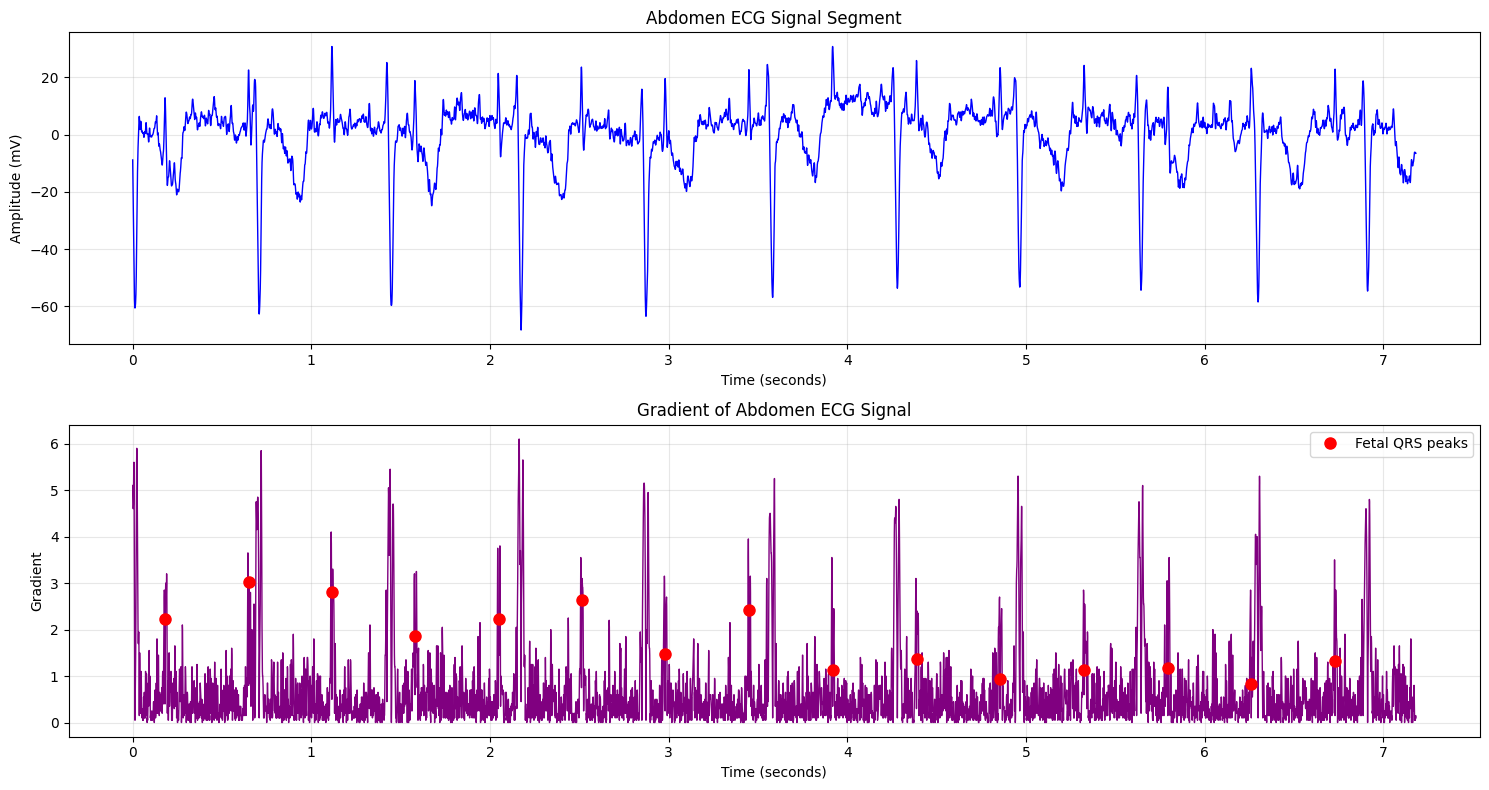

In [8]:
# Compute the gradient of the abdomen_signal
ecg_gradient = np.gradient(abdomen_signal_segment)
# absolute gradient values
ecg_gradient = np.abs(ecg_gradient)

plt.figure(figsize=(15, 8))

# Plot the original abdomen ECG signal segment
plt.subplot(2, 1, 1)
plt.plot(abdomen_time_segment, abdomen_signal_segment, color='blue', linewidth=1)
plt.title('Abdomen ECG Signal Segment')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)

# Plot the gradient of the abdomen ECG signal segment
plt.subplot(2, 1, 2)
plt.plot(abdomen_time_segment, ecg_gradient, color='purple', linewidth=1)
plt.plot(onsets_in_window, np.interp(onsets_in_window, abdomen_time_segment, ecg_gradient), 'ro', markersize=8, label='Fetal QRS peaks')
plt.legend()
plt.title('Gradient of Abdomen ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Gradient')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plot_fig_path, '3-gradient-abdomen-segment.png'))
plt.show()

In [9]:
def build_matrix(signal, row_length):
    # Idea: build a matrix where each row corresponds to a segment of the signal
    # Calculate the number of rows based on the signal length and row_length
    n_rows = len(signal) // row_length
    
    # For each row, take row_length samples from the signal (from i*row_length to (i+1)*row_length)
    # if i = 0, it takes signal[0*row_length:(0+1)*row_length]
    # if i = 1, it takes signal[1*row_length:(1+1)*row_length], etc.
    matrix = np.array([signal[i*row_length:(i+1)*row_length] for i in range(n_rows)])
    return matrix

def svr_spectrum(signal, n_min, n_max):
    sv_ratios = []  # To store singular value ratios
    n_values = range(n_min, n_max + 1)  # Generate a range of n values from n_min to n_max
    
    for n in n_values:
        # Build the matrix with the current row_length value n
        A = build_matrix(signal, n)
        if A.shape[0] < 2 or A.shape[1] < 2:
            sv_ratios.append(0)
            continue
        
        U, S, VT = np.linalg.svd(A, full_matrices=False)
        if len(S) >= 2 and S[1] != 0:
            # Calculate the ratio of sigma_2 on sigma
            sv_ratios.append(S[1] / S[0])
        else:
            sv_ratios.append(0)
    
    return list(n_values), sv_ratios

# Removed sliding window SVD extraction from here

Optimal period length: 716 samples


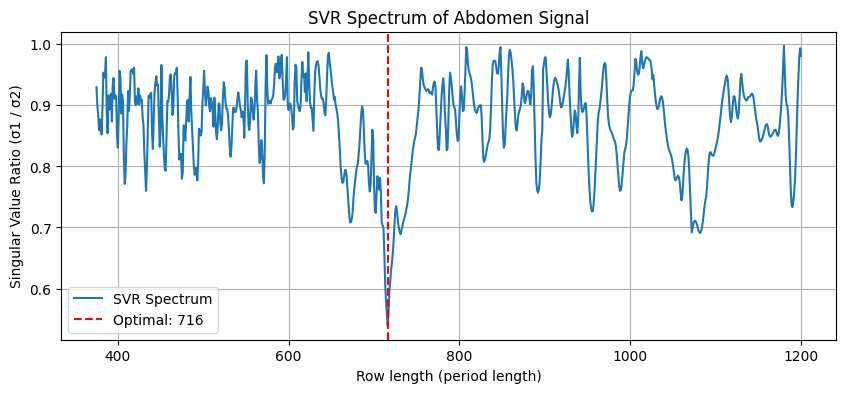

In [10]:
# Parameters
n_min = 375
n_max = 1200

# Compute SVR spectrum
n_vals, svrs = svr_spectrum(abdomen_signal_segment, n_min, n_max)

# Find optimal period (max SVR)
mecg_optimal_period = n_vals[np.argmin(svrs)]
print(f"Optimal period length: {mecg_optimal_period} samples")

# Plot SVR spectrum
plt.figure(figsize=(10, 4))
plt.plot(n_vals, svrs, label='SVR Spectrum')
plt.axvline(mecg_optimal_period, color='red', linestyle='--', label=f'Optimal: {mecg_optimal_period}')
plt.xlabel("Row length (period length)")
plt.ylabel("Singular Value Ratio (σ1 / σ2)")
plt.title("SVR Spectrum of Abdomen Signal")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(plot_fig_path, '4-mecg-optimal-period.png'))
plt.show()

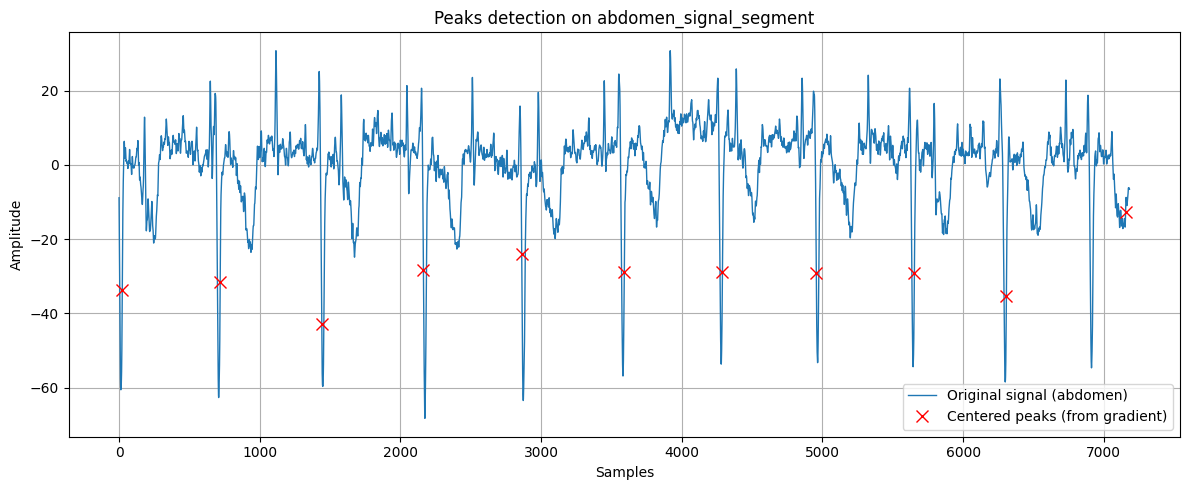

In [11]:
period_samples = int(0.8 * sampling_rate * 0.8)  # 80% del periodo

peaks, properties = find_peaks(ecg_gradient, distance=period_samples, prominence=0.5)

# Visualizza i risultati
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(abdomen_signal_segment, label='Original signal (abdomen)', linewidth=1)
plt.plot(peaks, abdomen_signal_segment[peaks], 'rx', label='Centered peaks (from gradient)', markersize=8)
plt.title('Peaks detection on abdomen_signal_segment')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()